<a href="https://colab.research.google.com/github/guneetnagia/LearnML/blob/clustering/clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [ ]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "unsupervised_learning"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

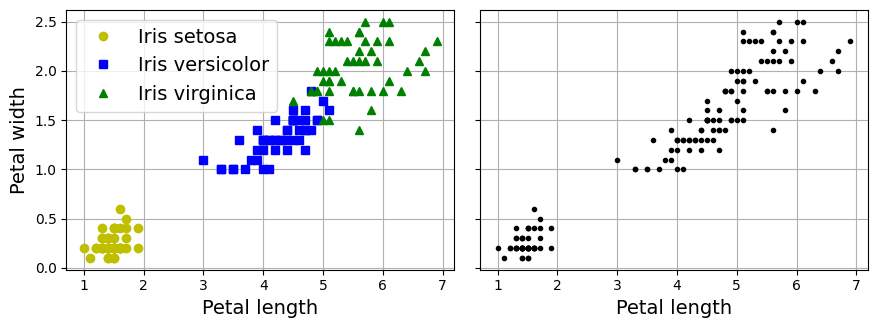

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target
data.target_names

plt.figure(figsize=(9, 3.5))

plt.subplot(121)
plt.plot(X[y==0, 2], X[y==0, 3], "yo", label="Iris setosa")
plt.plot(X[y==1, 2], X[y==1, 3], "bs", label="Iris versicolor")
plt.plot(X[y==2, 2], X[y==2, 3], "g^", label="Iris virginica")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.grid()
plt.legend()

plt.subplot(122)
plt.scatter(X[:, 2], X[:, 3], c="k", marker=".")
plt.xlabel("Petal length")
plt.tick_params(labelleft=False)
plt.gca().set_axisbelow(True)
plt.grid()

save_fig("classification_vs_clustering_plot")
plt.show()

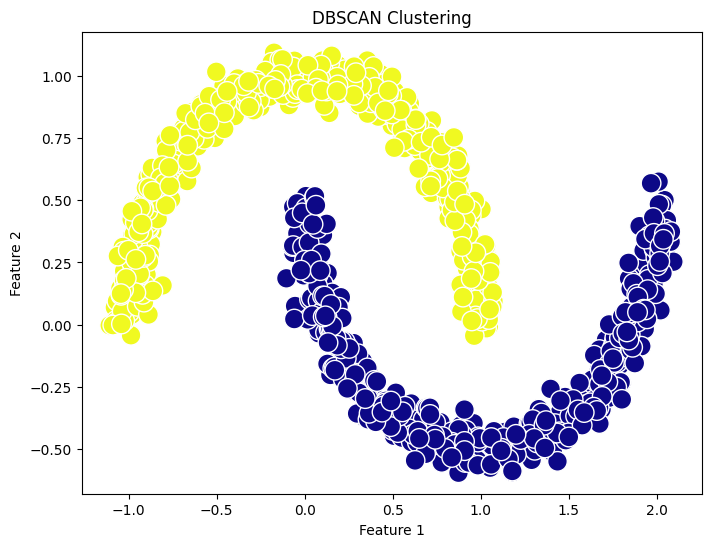

Cluster labels: [0 1]
Number of clusters found: 2


In [12]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X,y = make_moons(n_samples=
                 1000, noise=0.05)
dbscan = DBSCAN(eps=0.05, min_samples=5)
y_pred = dbscan.fit_predict(X)

#dbscan.labels_ ## -1 here is outlier
#dbscan.core_sample_indices_
#dbscan.components_

# 3. Plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap="plasma", s=50, edgecolors="k")

# Mark core samples (white edge)
core_samples_mask = np.zeros_like(y_pred, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True
plt.scatter(X[core_samples_mask, 0], X[core_samples_mask, 1],
            c=y_pred[core_samples_mask], cmap="plasma",
            s=200, marker="o", edgecolors="white", linewidths=1)

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# 4. Inspect clusters
print("Cluster labels:", np.unique(y_pred))   # -1 means noise
print("Number of clusters found:", len(set(y_pred)) - (1 if -1 in y_pred else 0))

## it identified quite a lot of anomalies, plus seven different clusters.
##How disappointing! Fortunately, if we widen each instance’s neighborhood
##by increasing eps to 0.2, we get the clustering on the right, which looks perfect.
## increase eps value from 0.05 to 0.2
